In [8]:
import pandas as pd

df = pd.read_csv(
    "commentaires_assurance_auto.csv",
    sep=";",
    header=None,
    engine="python",
    on_bad_lines="skip"
)

df.head()
df.shape


(8650, 14)

In [10]:
df.columns = [
    "id",
    "date",
    "device",
    "canal",
    "sentiment",
    "type_photo",
    "type_sinistre",
    "anciennete_client",
    "garantie",
    "csat",
    "gravite",
    "region",
    "source",
    "commentaire"
]

df.head()


,id,date,device,canal,sentiment,type_photo,type_sinistre,anciennete_client,garantie,csat,gravite,region,source,commentaire
0,1,2024-11-23,Android,Web,neg,photo,collision,3-10 ans,tous_risques,2,faible,Île-de-France,App,"Très mécontent, les photos restent en attente ..."
1,2,2024-03-22,iOS,App,neg,complexité,collision,0-1 an,tiers,2,moyenne,Pays de la Loire,Téléphone,"Je suis déçu, c'est trop technique pour un sin..."
2,3,2024-04-26,iOS,Email,pos,authentification,collision,3-10 ans,jeune_conducteur,4,faible,Auvergne-Rhône-Alpes,App,"Très satisfait, ça bloque sur l'authentificati..."
3,4,2024-04-22,iOS,Web,neu,photo,collision,1-3 ans,tiers,3,faible,Bourgogne-Franche-Comté,Email,"Ça pourrait être mieux, l'envoi des clichés éc..."
4,5,2024-10-02,Android,Web,pos,lenteur,collision,10+ ans,tous_risques,4,moyenne,Bretagne,App,"Merci, le site rame énormément quand je joins ..."


In [11]:
import spacy
import string

nlp = spacy.load("fr_core_news_md")

stopwords = nlp.Defaults.stop_words
punct = string.punctuation

# stopwords supplémentaires spécifiques aux verbatims clients
custom_stopwords = {
    "bonjour", "merci", "svp", "s'il", "plait", "problème", "problèmes",
    "application", "app", "site", "déclaration", "sinistre"
}
stopwords = stopwords.union(custom_stopwords)

def clean_advanced(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.text in punct:
            continue
        if token.is_stop:
            continue
        if token.like_num:
            continue
        lemma = token.lemma_.strip()
        if len(lemma) > 2:
            tokens.append(lemma)
    return " ".join(tokens)

df["commentaire_clean"] = df["commentaire"].apply(clean_advanced)


In [12]:
df[["commentaire", "commentaire_clean"]].head(10)


,commentaire,commentaire_clean
0,"Très mécontent, les photos restent en attente ...",mécontent photo attente fin formulaire essai c...
1,"Je suis déçu, c'est trop technique pour un sin...",décevoir trop technique sinistre simple perdre...
2,"Très satisfait, ça bloque sur l'authentificati...",satisfait bloquer authentification valide code...
3,"Ça pourrait être mieux, l'envoi des clichés éc...",mieux envoi cliché échouer étape justificatif ...
4,"Merci, le site rame énormément quand je joins ...",site rame énormément joindre pièce résolution ...
5,"Merci, ça me déconnecte tout seul sur mon télé...",déconnecter téléphone finaliser stress réponse...
6,"Je suis déçu, la caméra ne s'ouvre pas même en...",décevoir caméra ouvrir gramme perdre honnêteme...
7,"Je suis déçu, le parcours est confus pour une ...",décevoir parcours confus simple déclaration pe...
8,"Très satisfait, l'ajout des photos bloque au m...",satisfait ajout photo bloqu moment valider déb...
9,"Je suis déçu, l'application plante après la mi...",décevoir application plant mise jour perdre bl...


In [16]:
from sentence_transformers import SentenceTransformer

# Modèle multilingue performant pour le français
model_embed = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# On encode les commentaires nettoyés
texts = df["commentaire_clean"].tolist()
embeddings = model_embed.encode(texts, show_progress_bar=True)


c:\Users\Malaka\Desktop\Commentairecsv\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Malaka\Desktop\Commentairecsv\nlp_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Malaka\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or

In [17]:
from bertopic import BERTopic

topic_model = BERTopic(language="french")
topics, probs = topic_model.fit_transform(df["commentaire_clean"], embeddings)

df["topic"] = topics


In [18]:
topic_model.get_topic_info().head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1508,-1_simple_déclaration_bon_refaire,"[simple, déclaration, bon, refaire, fois, jour...",[terrible bon tourne rond écran simple déclara...
1,0,262,0_page_clic_figer_boucle,"[page, clic, figer, boucle, pièce, dernier, ma...",[décevoir page figer clic étape perdre honnête...
2,1,168,1_app_aider_support_réussir,"[app, aider, support, réussir, mitiger, limite...",[mieux envoi cliché échouer essai réussir fina...
3,2,129,2_nickel_début_débloquer_rapidement,"[nickel, début, débloquer, rapidement, rapide,...",[nickel envoi cliché échouer moment valider ré...
4,3,93,3_chargement_interminable_pièce_envoyer,"[chargement, interminable, pièce, envoyer, joi...",[franchement chargement interminable moment en...
5,4,92,4_nickel_finaliser_stress_continuer,"[nickel, finaliser, stress, continuer, réponse...",[mouliner fin étape finaliser stress réponse r...
6,5,91,5_caméra_ouvrir_fou_temps,"[caméra, ouvrir, fou, temps, perdre, formulair...",[inadmissible caméra ouvrir essai perdre perdr...
7,6,83,6_web_aider_support_globalement,"[web, aider, support, globalement, réussir, li...",[terrible bon envoi cliché échouer essai bref ...
8,7,82,7_application_plant_plante_appli,"[application, plant, plante, appli, dernier, c...",[franchement application plant passer étape es...
9,8,82,8_falloir_choisir_garage_comprendre,"[falloir, choisir, garage, comprendre, parcour...",[mécontent comprendre étape falloir choisir ga...


In [19]:
topic_model.get_topic(0)


[('page', np.float64(0.07008608790293769)),
 ('clic', np.float64(0.06006368825860381)),
 ('figer', np.float64(0.06006368825860381)),
 ('boucle', np.float64(0.04911562265002815)),
 ('pièce', np.float64(0.014277509521307283)),
 ('dernier', np.float64(0.014134734360931966)),
 ('matin', np.float64(0.012568281942500419)),
 ('soir', np.float64(0.011552530891964962)),
 ('hier', np.float64(0.011552530891964962)),
 ('confirmer', np.float64(0.008716924220652606))]

In [20]:
topic_model.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1508,-1_simple_déclaration_bon_refaire,"[simple, déclaration, bon, refaire, fois, jour...",[terrible bon tourne rond écran simple déclara...
1,0,262,0_page_clic_figer_boucle,"[page, clic, figer, boucle, pièce, dernier, ma...",[décevoir page figer clic étape perdre honnête...
2,1,168,1_app_aider_support_réussir,"[app, aider, support, réussir, mitiger, limite...",[mieux envoi cliché échouer essai réussir fina...
3,2,129,2_nickel_début_débloquer_rapidement,"[nickel, début, débloquer, rapidement, rapide,...",[nickel envoi cliché échouer moment valider ré...
4,3,93,3_chargement_interminable_pièce_envoyer,"[chargement, interminable, pièce, envoyer, joi...",[franchement chargement interminable moment en...
...,...,...,...,...,...
215,214,11,214_cliché_envoi_échouer_amélioration,"[cliché, envoi, échouer, amélioration, attendr...",[mieux envoi cliché échouer étape justificatif...
216,215,11,215_énormément_site_rame_manque,"[énormément, site, rame, manque, simplicité, p...",[mitiger site rame énormément étape devoir rep...
217,216,11,216_petit_impact_obligatoire_champ,"[petit, impact, obligatoire, champ, trop, tard...",[franchement trop champ obligatoire petit impa...
218,217,10,217_rapidement_début_débloquer_continuer,"[rapidement, début, débloquer, continuer, moul...",[mouliner fin étape début débloquer rapidement...


In [21]:
[("photo", 0.12), ("bloquer", 0.09), ("attente", 0.07), ...]


[('photo', 0.12), ('bloquer', 0.09), ('attente', 0.07), Ellipsis]

In [22]:
df[["commentaire", "topic"]].head(10)


,commentaire,topic
0,"Très mécontent, les photos restent en attente ...",10
1,"Je suis déçu, c'est trop technique pour un sin...",140
2,"Très satisfait, ça bloque sur l'authentificati...",-1
3,"Ça pourrait être mieux, l'envoi des clichés éc...",214
4,"Merci, le site rame énormément quand je joins ...",121
5,"Merci, ça me déconnecte tout seul sur mon télé...",-1
6,"Je suis déçu, la caméra ne s'ouvre pas même en...",-1
7,"Je suis déçu, le parcours est confus pour une ...",-1
8,"Très satisfait, l'ajout des photos bloque au m...",139
9,"Je suis déçu, l'application plante après la mi...",7


In [23]:
df[df["topic"] == 0]["commentaire"].head()


42     C'est mitigé, les pages se figent à chaque cli...
44     C'est mitigé, les pages se figent à chaque cli...
115    Pas terrible mais bon, les pages se figent à c...
136    Pas terrible mais bon, ça boucle sur la même p...
141    Pas terrible mais bon, les pages se figent à c...
Name: commentaire, dtype: object

In [28]:
topic_model.visualize_topics()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0, 'page | clic | figer | boucle | pièce', 262],
                                   [1, 'app | aider | support | réussir | mitiger', 168],
                                   [2, 'nickel | début | débloquer | rapidement | rapide', 129],
                                   ...,
                                   [216, 'petit | impact | obligatoire | champ | trop', 11],
                                   [217, 'rapidement | début | débloquer | continuer | mouliner', 10],
                                   [218, 'application | plant | confirmer | appli | plante', 10]],
                                  shape=(219, 3), dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
                         'size': {'bdata': ('BgGoAIEAXQBcAFsAUwBSAFIAUQBQAE' ... 'AMAAwADAAMAAwADAALAAsACwAKAAoA'),
                                  'dtype': 'i2'},
                         'sizemode': 'area',
                         'sizeref': 0.16375,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': ('AFUQQQiI7r4LFz8/cD2OwAPJVkFYGx' ... 'yxQPU/M0E09BNBblt4wI9+KUHbXgLB'),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('madrwMz82r+fGynBviOhQa0pkUDfzQ' ... 'msQUNjo0HKqNu+vzkuQQ7dFEH9pg1B'),
                    'dtype': 'f4'},
              'yaxis': 'y'}],
    'layout': {'annotations': [{'showarrow': False,
                                'text': 'D1',
                                'x': np.float32(-16.367184),
                                'y': np.float32(6.3417172),
                                'yshift': 10},
                               {'showarrow': False,
                                'text': 'D2',
                                'x': np.float32(4.864129),
                                'xshift': 10,
                                'y': np.float32(24.838064)}],
               'height': 650,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'itemsizing': 'constant', 'tracegroupgap': 0},
               'margin': {'t': 60},
               'shapes': [{'line': {'color': '#CFD8DC', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(4.864129),
                           'x1': np.float32(4.864129),
                           'y0': np.float32(-12.15463),
                           'y1': np.float32(24.838064)},
                          {'line': {'color': '#9E9E9E', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(-16.367184),
                           'x1': np.float32(26.095442),
                           'y0': np.float32(6.3417172),
                           'y1': np.float32(6.3417172)}],
               'sliders': [{'active': 0,
                            'pad': {'t': 50},
                            'steps': [{'args': [{'marker.color': [['red',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                             

In [27]:
import nbformat
nbformat.__version__


'5.10.4'

In [29]:
topic_model.visualize_hierarchy()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAAB8FKf7eB3CP3wUp/t4HcI/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAALsAAAAAAAAAuwAAAAAAAADnAAAAAAAAAOcA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAAA0Fw6BVWjOPzQXDoFVaM4/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAACAQcAAAAAAAIBBwAAAAAAAgEbAAAAAAACARsA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'fBSn+3gdwj/48cNTrYnWP/jxw1OtidY/NBcOgVVozj8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAANMAAAAAAAAA0wAAAAAAAAETAAAAAAAAARMA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': '+PHDU62J1j/SHGKOzl3ZP9IcYo7OXdk/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAAPsAAAAAAAAA+wAAAAAAAgEvAAAAAAACAS8A=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAAD83UxYUHzcP/zdTFhQfNw/0hxijs5d2T8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAAAAFMAAAAAAAAAUwAAAAAAAQEXAAAAAAABARcA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAACoJOXNkEC8P6gk5c2QQLw/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAABAUMAAAAAAAEBQwAAAAAAAwFLAAAAAAADAUsA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(61,153,112)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': '/N1MWFB83D/h+SptBUXhP+H5Km0FReE/qCTlzZBAvD8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAADAN8AAAAAAAMA3wAAAAAAAgFHAAAAAAACAUcA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(255,65,54)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAABIigm5nje7P0iKCbmeN7s/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAABAVcAAAAAAAEBVwAAAAAAAwFfAAAAAAADAV8A=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(255,65,54)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'AAAAAAAAAAAkl60fVh3PPySXrR9WHc8/AAAAAAAAAAA=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAABAWsAAAAAAAEBawAAAAAAAwFzAAAAAAADAXMA=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',
              'marker': {'color': 'rgb(255,65,54)'},
              'mode': 'lines',
              'type': 'scatter',
              'x': {'bdata': 'SIoJuZ43uz9FX//nQSPbP0Vf/+dBI9s/JJetH1Ydzz8=', 'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': 'AAAAAACAVsAAAAAAAIBWwAAAAAAAgFvAAAAAAACAW8A=', 'dtype': 'f8'},
              'yaxis': 'y'},
             {'hoverinfo': 'text',

In [30]:
topic_model.visualize_distribution(probs[0])


ValueError: This visualization cannot be used if you have set `calculate_probabilities` to False as it uses the topic probabilities of all topics. 

In [31]:
topic_model.get_topic_info().head(15)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1508,-1_simple_déclaration_bon_refaire,"[simple, déclaration, bon, refaire, fois, jour...",[terrible bon tourne rond écran simple déclara...
1,0,262,0_page_clic_figer_boucle,"[page, clic, figer, boucle, pièce, dernier, ma...",[décevoir page figer clic étape perdre honnête...
2,1,168,1_app_aider_support_réussir,"[app, aider, support, réussir, mitiger, limite...",[mieux envoi cliché échouer essai réussir fina...
3,2,129,2_nickel_début_débloquer_rapidement,"[nickel, début, débloquer, rapidement, rapide,...",[nickel envoi cliché échouer moment valider ré...
4,3,93,3_chargement_interminable_pièce_envoyer,"[chargement, interminable, pièce, envoyer, joi...",[franchement chargement interminable moment en...
5,4,92,4_nickel_finaliser_stress_continuer,"[nickel, finaliser, stress, continuer, réponse...",[mouliner fin étape finaliser stress réponse r...
6,5,91,5_caméra_ouvrir_fou_temps,"[caméra, ouvrir, fou, temps, perdre, formulair...",[inadmissible caméra ouvrir essai perdre perdr...
7,6,83,6_web_aider_support_globalement,"[web, aider, support, globalement, réussir, li...",[terrible bon envoi cliché échouer essai bref ...
8,7,82,7_application_plant_plante_appli,"[application, plant, plante, appli, dernier, c...",[franchement application plant passer étape es...
9,8,82,8_falloir_choisir_garage_comprendre,"[falloir, choisir, garage, comprendre, parcour...",[mécontent comprendre étape falloir choisir ga...


In [36]:
topic_labels = {
    -1: "Commentaires généraux / hors sujet",
    0: "Pages figées / clics inactifs",
    1: "Besoin d’aide / support insuffisant",
    2: "Blocage après un bon début",
    3: "Chargement interminable des pièces",
    4: "Finalisation impossible / stress",
    5: "Caméra qui ne s’ouvre pas",
    6: "Problèmes Web + besoin d’assistance",
    7: "Application qui plante",
    8: "Choix du garage / compréhension du parcours",
    9: "Parcours confus / onglets incompréhensibles",
    10: "Photos en attente / rien n’avance",
    11: "Difficulté à trouver sinistre / devis",
    12: "Scan de documents qui tourne en rond",
    13: "Joindre une image impossible"
}

# Ajouter automatiquement les thèmes manquants
for t in topic_model.get_topic_info()["Topic"].unique():
    if t not in topic_labels:
        topic_labels[t] = f"Thème {t} (à analyser)"


In [37]:
examples = {}

for t in df["topic"].unique():
    examples[t] = df[df["topic"] == t]["commentaire"].head(3).tolist()

examples


{np.int64(10): ["Très mécontent, les photos restent en attente à la fin du formulaire malgré plusieurs essais, du coup rien n'avance, merci quand même.",
  "Franchement, les photos restent en attente après trois essais malgré plusieurs essais, mais rien n'avance, merci de corriger vite.",
  "Je suis déçu, les photos restent en attente après trois essais, franchement rien n'avance, c'est pas sérieux."],
 np.int64(140): ["Je suis déçu, c'est trop technique pour un sinistre simple et je perds tout, franchement je perds un temps fou, c'est pas sérieux.",
  "Très mécontent, c'est trop technique alors que j'ai déjà envoyé et je perds tout, alors je perds un temps fou, je vais réessayer plus tard.",
  "Très mécontent, c'est trop technique alors que j'ai déjà envoyé, mais rien n'avance, je vais réessayer plus tard."],
 np.int64(-1): ["Très satisfait, ça bloque sur l'authentification quand je valide le code et j'ai pu finaliser sans stress, mais tout est bien expliqué, bravo à l'équipe.",
  "Me

In [40]:
rows = []

for _, row in topic_model.get_topic_info().iterrows():
    t = row["Topic"]
    if t == -1:
        continue

    rows.append({
        "Topic": t,
        "Nom du thème": topic_labels[t],
        "Volume": row["Count"],
        "Mots-clés": ", ".join([w for w, _ in topic_model.get_topic(t)]),
        "Exemple": df[df["topic"] == t]["commentaire"].iloc[0]
    })

tableau_final = pd.DataFrame(rows)
tableau_final


,Topic,Nom du thème,Volume,Mots-clés,Exemple
0,0,Pages figées / clics inactifs,262,"page, clic, figer, boucle, pièce, dernier, mat...","C'est mitigé, les pages se figent à chaque cli..."
1,1,Besoin d’aide / support insuffisant,168,"app, aider, support, réussir, mitiger, limite,...","Ça pourrait être mieux, l'envoi des clichés éc..."
2,2,Blocage après un bon début,129,"nickel, début, débloquer, rapidement, rapide, ...",Nickel je n'arrive pas à trouver où suivre mon...
3,3,Chargement interminable des pièces,93,"chargement, interminable, pièce, envoyer, join...","Ras-le-bol, le chargement est interminable à c..."
4,4,Finalisation impossible / stress,92,"nickel, finaliser, stress, continuer, réponse,...","Très satisfait, l'envoi des clichés échoue apr..."
...,...,...,...,...,...
214,214,Thème 214 (à analyser),11,"cliché, envoi, échouer, amélioration, attendre...","Ça pourrait être mieux, l'envoi des clichés éc..."
215,215,Thème 215 (à analyser),11,"énormément, site, rame, manque, simplicité, pi...","Ça pourrait être mieux, le site rame énormémen..."
216,216,Thème 216 (à analyser),11,"petit, impact, obligatoire, champ, trop, tard,...","Franchement, trop de champs obligatoires pour ..."
217,217,Thème 217 (à analyser),10,"rapidement, début, débloquer, continuer, mouli...",Très satisfait ça me déconnecte tout seul sur ...


In [39]:
synthese = []

for _, row in tableau_final.iterrows():
    synthese.append(
        f"- **{row['Nom du thème']}** ({row['Volume']} verbatims) : {row['Mots-clés'][:80]}..."
    )

print("\n".join(synthese))


- **Pages figées / clics inactifs** (262 verbatims) : page, clic, figer, boucle, pièce, dernier, matin, soir, hier, confirmer...
- **Besoin d’aide / support insuffisant** (168 verbatims) : app, aider, support, réussir, mitiger, limite, globalement, passer, reprendre, f...
- **Blocage après un bon début** (129 verbatims) : nickel, début, débloquer, rapidement, rapide, résolution, être, efficace, suivi,...
- **Chargement interminable des pièces** (93 verbatims) : chargement, interminable, pièce, envoyer, joindre, moment, tard, réessayer, étap...
- **Finalisation impossible / stress** (92 verbatims) : nickel, finaliser, stress, continuer, réponse, bien, expliquer, équipe, service,...
- **Caméra qui ne s’ouvre pas** (91 verbatims) : caméra, ouvrir, fou, temps, perdre, formulaire, valider, moment, fin, méconter...
- **Problèmes Web + besoin d’assistance** (83 verbatims) : web, aider, support, globalement, réussir, limite, final, passer, mitiger, techn...
- **Application qui plante** (82 ver

In [41]:
actions = {}

for t in tableau_final["Topic"]:
    mots = [w for w, _ in topic_model.get_topic(t)]
    
    if "caméra" in mots:
        actions[t] = "Stabiliser l’ouverture de la caméra (Android + iOS)."
    elif "chargement" in mots or "interminable" in mots:
        actions[t] = "Optimiser les temps de chargement et l’envoi des pièces."
    elif "parcours" in mots or "confus" in mots:
        actions[t] = "Simplifier le parcours et clarifier les étapes."
    elif "application" in mots or "plant" in mots:
        actions[t] = "Corriger les crashs et améliorer la stabilité de l’application."
    elif "photo" in mots and "attente" in mots:
        actions[t] = "Corriger le blocage des photos en attente."
    else:
        actions[t] = "Analyser plus en détail pour définir une action corrective."

actions


{0: 'Analyser plus en détail pour définir une action corrective.',
 1: 'Analyser plus en détail pour définir une action corrective.',
 2: 'Analyser plus en détail pour définir une action corrective.',
 3: 'Optimiser les temps de chargement et l’envoi des pièces.',
 4: 'Analyser plus en détail pour définir une action corrective.',
 5: 'Stabiliser l’ouverture de la caméra (Android + iOS).',
 6: 'Analyser plus en détail pour définir une action corrective.',
 7: 'Corriger les crashs et améliorer la stabilité de l’application.',
 8: 'Simplifier le parcours et clarifier les étapes.',
 9: 'Simplifier le parcours et clarifier les étapes.',
 10: 'Corriger le blocage des photos en attente.',
 11: 'Analyser plus en détail pour définir une action corrective.',
 12: 'Analyser plus en détail pour définir une action corrective.',
 13: 'Analyser plus en détail pour définir une action corrective.',
 14: 'Analyser plus en détail pour définir une action corrective.',
 15: 'Analyser plus en détail pour dé

In [42]:
# 1) Récupérer les mots-clés par thème
keywords = {
    t: ", ".join([w for w, _ in topic_model.get_topic(t)])
    for t in topic_model.get_topic_info()["Topic"].unique()
    if t != -1
}

# 2) Ajouter les mots-clés dans le dataframe
df["keywords"] = df["topic"].map(keywords)

# 3) Ajouter les labels
df["topic_label"] = df["topic"].map(topic_labels)

# 4) Exporter le fichier final
df.to_csv("resultats_analyse_commentaires.csv", sep=";", index=False)


In [43]:
df.groupby(["device", "topic_label"]).size().unstack(fill_value=0)


topic_label,Application qui plante,Besoin d’aide / support insuffisant,Blocage après un bon début,Caméra qui ne s’ouvre pas,Chargement interminable des pièces,Choix du garage / compréhension du parcours,Commentaires généraux / hors sujet,Difficulté à trouver sinistre / devis,Finalisation impossible / stress,Joindre une image impossible,...,Thème 90 (à analyser),Thème 91 (à analyser),Thème 92 (à analyser),Thème 93 (à analyser),Thème 94 (à analyser),Thème 95 (à analyser),Thème 96 (à analyser),Thème 97 (à analyser),Thème 98 (à analyser),Thème 99 (à analyser)
device,,,,,,,,,,,,,,,,,,,,,
Android,39,84,57,36,44,42,691,38,39,27,...,14,13,13,11,15,13,12,13,10,13
Web,17,27,27,16,18,16,332,13,26,15,...,6,4,7,8,3,5,8,4,10,5
iOS,26,57,45,39,31,24,485,24,27,26,...,9,12,9,9,10,10,8,11,8,9


In [44]:
df.groupby(["canal", "topic_label"]).size().unstack(fill_value=0)


topic_label,Application qui plante,Besoin d’aide / support insuffisant,Blocage après un bon début,Caméra qui ne s’ouvre pas,Chargement interminable des pièces,Choix du garage / compréhension du parcours,Commentaires généraux / hors sujet,Difficulté à trouver sinistre / devis,Finalisation impossible / stress,Joindre une image impossible,...,Thème 90 (à analyser),Thème 91 (à analyser),Thème 92 (à analyser),Thème 93 (à analyser),Thème 94 (à analyser),Thème 95 (à analyser),Thème 96 (à analyser),Thème 97 (à analyser),Thème 98 (à analyser),Thème 99 (à analyser)
canal,,,,,,,,,,,,,,,,,,,,,
Agence,1,0,2,0,2,1,12,1,1,1,...,1,1,0,1,2,0,1,0,0,0
App,49,94,75,55,45,48,829,40,44,43,...,14,15,15,15,16,17,19,16,13,15
Email,3,10,9,5,4,2,49,4,3,4,...,0,2,1,1,0,1,0,0,2,1
Téléphone,9,16,7,5,8,8,135,7,12,6,...,5,3,4,2,5,1,4,1,1,3
Web,20,48,36,26,34,23,483,23,32,14,...,9,8,9,9,5,9,4,11,12,8


In [45]:
df.groupby(["region", "topic_label"]).size().unstack(fill_value=0)


topic_label,Application qui plante,Besoin d’aide / support insuffisant,Blocage après un bon début,Caméra qui ne s’ouvre pas,Chargement interminable des pièces,Choix du garage / compréhension du parcours,Commentaires généraux / hors sujet,Difficulté à trouver sinistre / devis,Finalisation impossible / stress,Joindre une image impossible,...,Thème 90 (à analyser),Thème 91 (à analyser),Thème 92 (à analyser),Thème 93 (à analyser),Thème 94 (à analyser),Thème 95 (à analyser),Thème 96 (à analyser),Thème 97 (à analyser),Thème 98 (à analyser),Thème 99 (à analyser)
region,,,,,,,,,,,,,,,,,,,,,
Auvergne-Rhône-Alpes,20,21,12,11,11,12,190,6,12,6,...,3,6,4,3,1,3,7,5,3,2
Bourgogne-Franche-Comté,2,7,4,2,2,4,61,1,2,1,...,1,1,1,2,2,1,3,0,0,0
Bretagne,3,10,1,5,8,5,72,7,5,6,...,1,1,2,2,0,0,0,3,2,1
Centre-Val de Loire,1,3,6,2,2,1,43,2,5,0,...,1,0,0,3,1,1,1,0,0,0
Grand Est,9,12,10,7,8,5,116,8,6,4,...,1,0,1,4,2,0,0,4,5,5
Hauts-de-France,4,18,11,7,9,7,110,6,6,2,...,3,1,1,3,0,3,2,1,2,2
Normandie,4,10,5,5,7,7,77,4,7,8,...,2,3,1,4,0,1,3,0,1,1
Nouvelle-Aquitaine,3,19,18,11,7,4,158,10,6,9,...,1,2,5,0,4,2,3,5,4,3
Occitanie,7,17,15,13,11,6,169,5,14,3,...,4,4,4,1,4,4,1,2,2,5


In [46]:
df.groupby(["sentiment", "topic_label"]).size().unstack(fill_value=0)


topic_label,Application qui plante,Besoin d’aide / support insuffisant,Blocage après un bon début,Caméra qui ne s’ouvre pas,Chargement interminable des pièces,Choix du garage / compréhension du parcours,Commentaires généraux / hors sujet,Difficulté à trouver sinistre / devis,Finalisation impossible / stress,Joindre une image impossible,...,Thème 90 (à analyser),Thème 91 (à analyser),Thème 92 (à analyser),Thème 93 (à analyser),Thème 94 (à analyser),Thème 95 (à analyser),Thème 96 (à analyser),Thème 97 (à analyser),Thème 98 (à analyser),Thème 99 (à analyser)
sentiment,,,,,,,,,,,,,,,,,,,,,
neg,69,0,0,91,68,58,844,72,0,68,...,29,17,0,28,0,0,16,0,24,27
neu,12,168,0,0,25,24,427,3,0,0,...,0,6,29,0,28,0,11,28,4,0
pos,1,0,129,0,0,0,237,0,92,0,...,0,6,0,0,0,28,1,0,0,0


In [47]:
df[df["device"] == "Android"]["topic_label"].value_counts().head(3)


topic_label
Commentaires généraux / hors sujet     691
Pages figées / clics inactifs          130
Besoin d’aide / support insuffisant     84
Name: count, dtype: int64

In [48]:
rapport = []

rapport.append("=== SYNTHÈSE DES IRRITANTS CLIENTS ===\n")

for t in tableau_final["Topic"]:
    nom = topic_labels[t]
    vol = tableau_final[tableau_final["Topic"] == t]["Volume"].iloc[0]
    mots = tableau_final[tableau_final["Topic"] == t]["Mots-clés"].iloc[0]
    exemple = tableau_final[tableau_final["Topic"] == t]["Exemple"].iloc[0]

    rapport.append(f"\n--- {nom} ({vol} verbatims) ---")
    rapport.append(f"Mots-clés : {mots}")
    rapport.append(f"Exemple : {exemple}")

rapport_text = "\n".join(rapport)

print(rapport_text)


=== SYNTHÈSE DES IRRITANTS CLIENTS ===


--- Pages figées / clics inactifs (262 verbatims) ---
Mots-clés : page, clic, figer, boucle, pièce, dernier, matin, soir, hier, confirmer
Exemple : C'est mitigé, les pages se figent à chaque clic à chaque étape, et j'ai réussi au final, ça manque de simplicité.

--- Besoin d’aide / support insuffisant (168 verbatims) ---
Mots-clés : app, aider, support, réussir, mitiger, limite, globalement, passer, reprendre, final
Exemple : Ça pourrait être mieux, l'envoi des clichés échoue à la fin du formulaire, donc j'ai dû m'y reprendre, le support via app a aidé.

--- Blocage après un bon début (129 verbatims) ---
Mots-clés : nickel, début, débloquer, rapidement, rapide, résolution, être, efficace, suivi, service
Exemple : Nickel je n'arrive pas à trouver où suivre mon sinistre sur le récapitulatif mais la résolution a été rapide bref j'ai eu une réponse rapide.

--- Chargement interminable des pièces (93 verbatims) ---
Mots-clés : chargement, interminabl

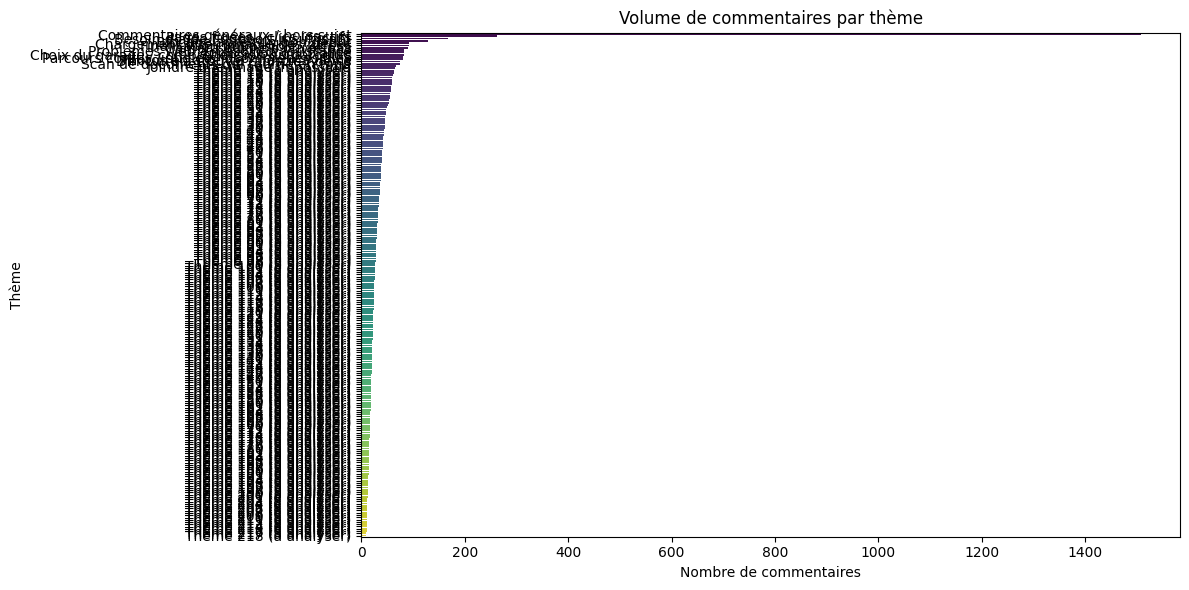

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compter les thèmes
theme_counts = df["topic_label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=theme_counts.values, y=theme_counts.index, palette="viridis")
plt.title("Volume de commentaires par thème")
plt.xlabel("Nombre de commentaires")
plt.ylabel("Thème")
plt.tight_layout()
plt.show()


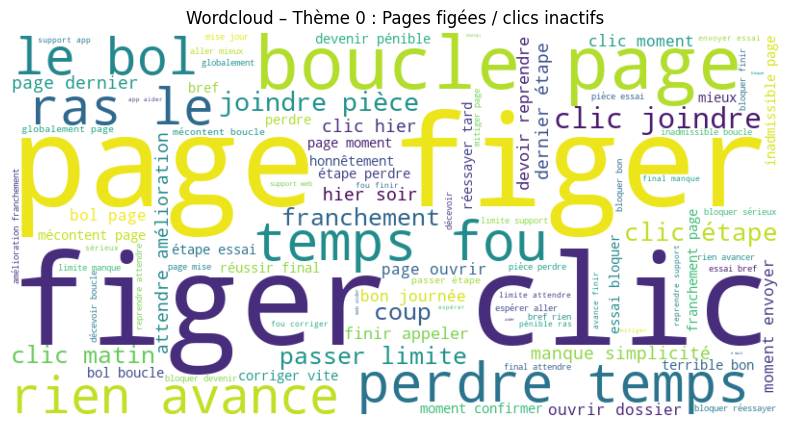

In [53]:
from wordcloud import WordCloud

def plot_wordcloud(topic_id):
    text = " ".join(df[df["topic"] == topic_id]["commentaire_clean"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud – Thème {topic_id} : {topic_labels[topic_id]}")
    plt.show()

# Exemple : wordcloud du thème 0
plot_wordcloud(0)
